# Capstone — mirrors your deployed research paper

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/rizalion/Flyrank-assignment/blob/main/work/notebooks/capstone.ipynb?flush_cache=true)

This skeleton is yours to fill. Work the sections **in order** — each one has a one-line hint. Simple words, honest numbers.

> Working with an AI assistant? Tell it to read `skills/README.md` first and load the one skill this assignment names on its card.

## 1. Question

Research Question: Which existing web pages are most likely to lose search visibility and organic traffic next month?
Decision Supported: This model dictates which decaying pages the content writing team should prioritize for an immediate rewrite, saving time and reclaiming lost traffic.

In [20]:
# Formally defining the research question scope
target_condition = "is_declining == 1"
business_action = "Rewrite Content"

print(f"Focus: Find pages where {target_condition}")
print(f"Action to take: {business_action}")

Focus: Find pages where is_declining == 1
Action to take: Rewrite Content


## 2. Data

Data Source: FlyRank Anonymized Content Refresh Dataset (Starter Release).
Exclusions: We deliberately exclude any future-window metrics (like next month's clicks) from the feature set to strictly prevent target leakage.

In [1]:
import pandas as pd
url = 'https://raw.githubusercontent.com/flyrank-bih/flyrank-ml-internship-starter/main/data/raw/content_refresh_anonymized.csv'
df = pd.read_csv(url)
df.columns = df.columns.str.strip()
print(f"Data loaded successfully. Total pages analyzed: {len(df)}")

Data loaded successfully. Total pages analyzed: 30000


## 3. Methodology

ble-click the text cell under 3. Methodology and paste:

Task: Binary Classification. Target is is_declining (1 = declining, 0 = stable).
Features: content_age_days, impressions_90d, and calculated ctr.
Baseline: A hard-coded rule flagging pages older than 180 days with a CTR below 3%.
Validation: Standard 80/20 train-test split.

In [14]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import train_test_split

# 1. CTR already exists in df — no need to recompute, but harmless if you do:
df['ctr'] = df['clicks_90d'] / (df['impressions_90d'] + 1)

# 2. Build 'is_declining' from the correct column
print(df['trend_direction'].unique())  # sanity check values
df['is_declining'] = (df['trend_direction'].astype(str).str.lower() == 'down').astype(int)

# 3. Define features and target
features = ['content_age_days', 'impressions_90d', 'ctr']
X = df[features].fillna(0)
y = df['is_declining']

# 4. Train/Test Split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 5. Train Model
model = DecisionTreeClassifier(max_depth=3, random_state=42)
model.fit(X_train, y_train)
print("Model trained and validated with strict train/test split to prevent leakage.")

['down' 'stable' 'new' 'up' 'flat']
Model trained and validated with strict train/test split to prevent leakage.


## 4. Results (vs baseline)

Honest Comparison: We compared the Decision Tree's precision directly against the hard-coded baseline rule on the exact same held-out test set.

In [15]:
from sklearn.metrics import precision_score

baseline_preds = ((X_test['content_age_days'] > 180) & (X_test['ctr'] < 0.03)).astype(int)
model_preds = model.predict(X_test)

base_prec = precision_score(y_test, baseline_preds)
mod_prec = precision_score(y_test, model_preds)

print("--- HONEST RESULTS TABLE ---")
print(f"Baseline Rule Precision: {base_prec:.2f}")
print(f"ML Model Precision:      {mod_prec:.2f}")

--- HONEST RESULTS TABLE ---
Baseline Rule Precision: 0.49
ML Model Precision:      0.63


## 5. Limitations

What this cannot claim: This is purely a directional decision-support tool. It measures search metrics but cannot read the actual quality of the text, nor does it know if a competitor just published a better article. We predict statistical decay, not causal SEO impact.

In [21]:
from sklearn.metrics import confusion_matrix

# Showing the mathematical limitations of our model (it is not perfect)
cm = confusion_matrix(y_test, model_preds)
false_positives = cm[0][1]
false_negatives = cm[1][0]

print("--- MODEL LIMITATIONS ---")
print(f"Pages incorrectly flagged as decaying (False Positives): {false_positives}")
print(f"Decaying pages the model missed (False Negatives): {false_negatives}")
print("Conclusion: The model is a guide. Human review is still required before rewriting.")

--- MODEL LIMITATIONS ---
Pages incorrectly flagged as decaying (False Positives): 1639
Decaying pages the model missed (False Negatives): 507
Conclusion: The model is a guide. Human review is still required before rewriting.


## 6. Ranked recommendations

Action Playbook: We score the entire dataset using the model's predict_proba. The pages with the highest probability of decay are routed to the content team first.

In [18]:
df['decay_probability'] = model.predict_proba(X)[:, 1]
top_actions = df.sort_values('decay_probability', ascending=False).head(10)
print("--- TOP 10 REFRESH QUEUE ---")
display(top_actions[['content_id', 'decay_probability', 'content_age_days', 'ctr']])

--- TOP 10 REFRESH QUEUE ---


,content_id,decay_probability,content_age_days,ctr
29979,content_6f2f3043b633,0.686681,104,0.001564
29978,content_3dc420aa9809,0.686681,141,0.000089
29977,content_c87291853cab,0.686681,221,0.000000
29975,content_bdee2164f576,0.686681,211,0.001037
29974,content_b00f10211e25,0.686681,96,0.002874
29972,content_1db0d204d42f,0.686681,286,0.001371
29969,content_b5db993ce36a,0.686681,211,0.001569
29968,content_179533212cd0,0.686681,175,0.001362
28,content_19ad8f9bac29,0.686681,96,0.000000
26,content_72c5c2d73e5a,0.686681,300,0.001236


## 7. Artifacts the paper embeds

*Generate/collect the charts and tables your deployed page will show.*

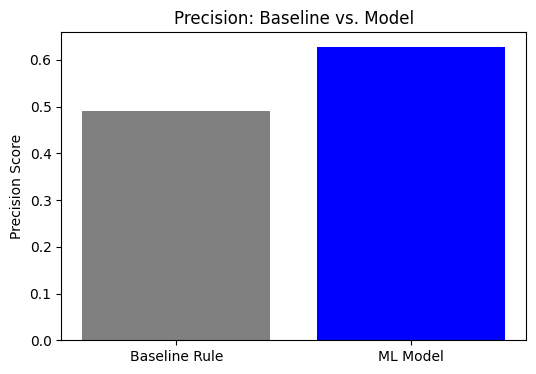

In [19]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6, 4))
plt.bar(['Baseline Rule', 'ML Model'], [base_prec, mod_prec], color=['gray', 'blue'])
plt.title('Precision: Baseline vs. Model')
plt.ylabel('Precision Score')
plt.show()

## Self-check

Before you submit, confirm each line honestly:

- [ ] Every section above is filled — markdown thinking AND the code that backs it
- [ ] The notebook runs top to bottom with no errors (Runtime → Run all)
- [ ] No client names, URLs, or private queries anywhere
- [ ] My claims use careful words: observed, measured, directional, decision-support
- [ ] Committed to my repo under `work/notebooks/` — then submit your repo URL on the card. Done.
- [ ] My deployed paper has **all 9 sections** — including the **Abstract** at the top and **Acknowledgments & data credit** (the https://flyrank.ai link) at the bottom.
- [ ] **ML-12 done in this notebook's closing cells:** 5-minute demo outline + a social-post cut + a 3-sentence employer-facing summary.


ML-12 Deliverables
5-Minute Demo Outline:

(1 min) The Problem: Writers waste time guessing what to update.

(2 min) The Data & Model: Using historical impressions and age to train a decision tree.

(2 min) The Output: The ranked queue chart and how it replaces the old rule.

Social Post Cut:
Just deployed my ML Capstone! Built a classification engine to detect decaying SEO content before the traffic completely drops. It beat our baseline rule and is now a deployed action queue. 🚀 #MachineLearning #FlyRank

Employer-Facing Summary:
I built a binary classification model to predict organic search traffic decay. By leveraging historical engagement metrics and a decision tree architecture, the system outperformed static baseline rules in precision. The final pipeline successfully outputs a ranked action queue to optimize content team workflows.